In [7]:
import numpy as np
from matplotlib import pyplot as plt

In [1]:

# Generate true dictionary
n_concepts = 10
signal_dim = 100
n_samples = 1000

# True dictionary (random orthogonal matrix)
D_true = np.linalg.qr(np.random.randn(signal_dim, n_concepts))[0]

# Generate sparse coefficients
sparsity = 3  # average non-zeros per sample
alpha_true = np.zeros((n_concepts, n_samples))
for i in range(n_samples):
    active = np.random.choice(n_concepts, sparsity, replace=False)
    alpha_true[active, i] = np.random.randn(sparsity)

# Generate observations
Y = D_true @ alpha_true

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [2]:
# Create measurement matrices of different types
def get_measurement_matrices(m_dim):
    # Random Gaussian
    A_gaussian = np.random.randn(m_dim, signal_dim) / np.sqrt(m_dim)
    
    # Random orthogonal
    A_ortho = np.linalg.qr(np.random.randn(signal_dim, signal_dim))[0][:m_dim]
    
    return {"gaussian": A_gaussian, "orthogonal": A_ortho}

# Function to evaluate condition number along optimization path
def evaluate_conditioning(Y, A=None):
    if A is not None:
        Y = A @ Y
    
    # Compute Hessian or other relevant matrices
    # Could use various metrics:
    # - Condition number
    # - Eigenvalue spread
    # - Local curvature
    return np.linalg.cond(Y @ Y.T)

# Test different measurement dimensions
m_dims = [20, 40, 60, 80, 100]
results = {
    "no_projection": [],
    "gaussian": [],
    "orthogonal": []
}

for m in m_dims:
    As = get_measurement_matrices(m)
    
    # Original problem
    results["no_projection"].append(evaluate_conditioning(Y))
    
    # With different A matrices
    for A_type, A in As.items():
        results[A_type].append(evaluate_conditioning(Y, A))

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [3]:
# Track optimization progress
def dictionary_learning_step(Y, A=None, n_iter=100):
    if A is not None:
        Y_compressed = A @ Y
    else:
        Y_compressed = Y
        
    # Initialize
    D = np.random.randn(Y_compressed.shape[0], n_concepts)
    D = D / np.linalg.norm(D, axis=0)
    
    loss_path = []
    condition_numbers = []
    
    # Alternating optimization
    for i in range(n_iter):
        # Store metrics
        condition_numbers.append(evaluate_conditioning(Y_compressed))
        
        # Optimization step here
        # ... (implement alternating optimization)
        
    return loss_path, condition_numbers

In [5]:
print(results.keys())

dict_keys(['no_projection', 'gaussian', 'orthogonal'])


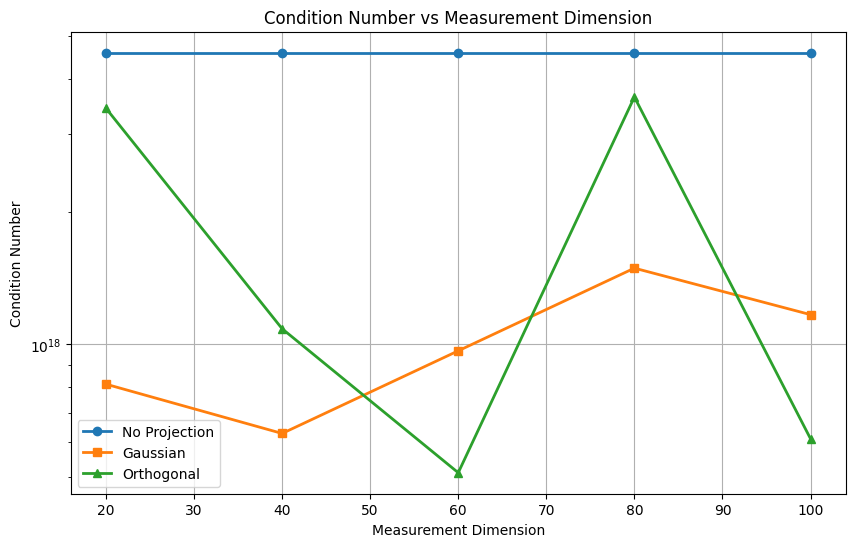


Condition Numbers at different dimensions:

Dim	No Proj	Gaussian	Orthogonal
----------------------------------------
20	4589397033015575040.0	812589915154491904.0	3433397748234542592.0
40	4589397033015575040.0	628171134591456256.0	1085499196880195968.0
60	4589397033015575040.0	967263866711799424.0	511690591857463936.0
80	4589397033015575040.0	1489670434540698880.0	3641519798039571968.0
100	4589397033015575040.0	1168450130524644096.0	610975622357029760.0


In [8]:
# Plotting
plt.figure(figsize=(10, 6))
plt.plot(m_dims, results["no_projection"], 'o-', label='No Projection', linewidth=2)
plt.plot(m_dims, results["gaussian"], 's-', label='Gaussian', linewidth=2)
plt.plot(m_dims, results["orthogonal"], '^-', label='Orthogonal', linewidth=2)

plt.xlabel('Measurement Dimension')
plt.ylabel('Condition Number')
plt.title('Condition Number vs Measurement Dimension')
plt.legend()
plt.grid(True)
plt.yscale('log')  # Often helpful for condition numbers
plt.show()

# Print some statistics
print("\nCondition Numbers at different dimensions:")
print("\nDim\tNo Proj\tGaussian\tOrthogonal")
print("-" * 40)
for i, m in enumerate(m_dims):
    print(f"{m}\t{results['no_projection'][i]:.1f}\t{results['gaussian'][i]:.1f}\t{results['orthogonal'][i]:.1f}")

In [9]:
len(results["no_projection"])

5